In [ ]:
import json, os
kaggle_creds = {
    "username": "muzammilfar00q",
    "key": "KGAT_353c38085bd0e7cad188e3fad4a4bbf4"
}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle API ready!")

Kaggle API ready!


In [ ]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plantvillage
print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:39<00:00, 17.5MB/s]

Dataset downloaded!


In [ ]:
import os
dataset_path = '/content/plantvillage/PlantVillage'
classes = sorted(os.listdir(dataset_path))
print(f"Total classes: {len(classes)}")
print("\nFirst 10 classes:")
for c in classes[:10]:
    count = len(os.listdir(os.path.join(dataset_path, c)))
    print(f"  {c}: {count} images")

Total classes: 15

First 10 classes:
  Pepper__bell___Bacterial_spot: 997 images
  Pepper__bell___healthy: 1478 images
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images
  Tomato_Bacterial_spot: 2127 images
  Tomato_Early_blight: 1000 images
  Tomato_Late_blight: 1909 images
  Tomato_Leaf_Mold: 952 images
  Tomato_Septoria_leaf_spot: 1771 images


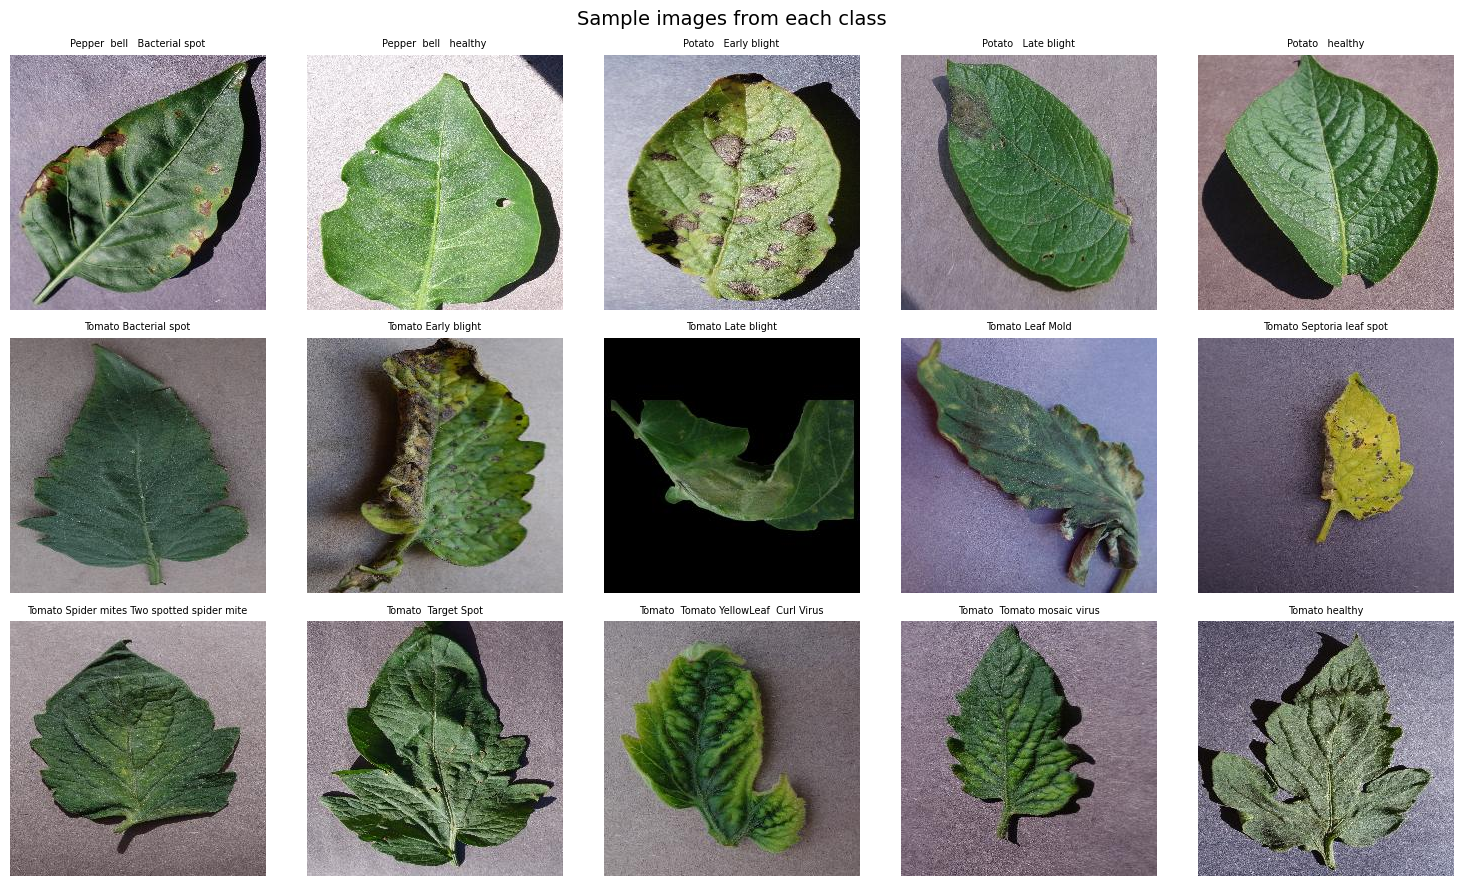

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()
for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    img_file = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(class_name.replace('_', ' '), fontsize=7)
    axes[i].axis('off')
plt.suptitle('Sample images from each class', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# Data augmentation for training, just rescaling for val/test
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)
val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
print(f"\nTraining images:   {train_data.samples}")
print(f"Validation images: {val_data.samples}")
print(f"Number of classes: {train_data.num_classes}")

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.

Training images:   16516
Validation images: 4122
Number of classes: 15


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
# Load MobileNetV2 pretrained on ImageNet, without the top layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze the base model — we don't want to retrain it
base_model.trainable = False
# Add our own classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(15, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model built successfully!")
print(f"Total layers: {len(model.layers)}")
print(f"Trainable layers: {sum(1 for l in model.layers if l.trainable)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model built successfully!
Total layers: 158
Trainable layers: 4


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# Stop training if validation accuracy stops improving
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)
# Save the best model automatically
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
print("Starting training...")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Starting training...
Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.6365 - loss: 1.1630
Epoch 1: val_accuracy improved from None to 0.84134, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 250s 444ms/step - accuracy: 0.7468 - loss: 0.7858 - val_accuracy: 0.8413 - val_loss: 0.4633
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8304 - loss: 0.4944
Epoch 2: val_accuracy improved from 0.84134 to 0.85978, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 199s 386ms/step - accuracy: 0.8394 - loss: 0.4736 - val_accuracy: 0.8598 - val_loss: 0.3915
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8608 - loss: 0.4136
Epoch 3: val_accuracy improved from 0.85978 to 0.88404, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 198s 382ms/step - accuracy: 0.8599 - loss: 0.4146 - val_accuracy: 0.8840 - val_loss: 0.3566
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8655 - loss: 0.3867
Epoch 4: val_accuracy did not improve from 0.88404
517/517 ━━━━━━━━━━━━━━━━━━━━ 203s 392ms/step - accuracy: 0.8670 - loss: 0.3856 - val_accuracy: 0.8826 - val_loss: 0.3399
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.8707 - loss: 0.3792
Epoch 5: val_accuracy improved from 0.88404 to 0.89010, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 199s 385ms/step - accuracy: 0.8724 - loss: 0.3766 - val_accuracy: 0.8901 - val_loss: 0.3158
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8822 - loss: 0.3433
Epoch 6: val_accuracy improved from 0.89010 to 0.89398, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 198s 383ms/step - accuracy: 0.8799 - loss: 0.3514 - val_accuracy: 0.8940 - val_loss: 0.2947
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.8873 - loss: 0.3310
Epoch 7: val_accuracy did not improve from 0.89398
517/517 ━━━━━━━━━━━━━━━━━━━━ 196s 380ms/step - accuracy: 0.8857 - loss: 0.3318 - val_accuracy: 0.8857 - val_loss: 0.3326
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.8862 - loss: 0.3272
Epoch 8: val_accuracy improved from 0.89398 to 0.89835, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 197s 381ms/step - accuracy: 0.8884 - loss: 0.3240 - val_accuracy: 0.8984 - val_loss: 0.2999
Epoch 9/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8871 - loss: 0.3153
Epoch 9: val_accuracy did not improve from 0.89835
517/517 ━━━━━━━━━━━━━━━━━━━━ 197s 381ms/step - accuracy: 0.8914 - loss: 0.3103 - val_accuracy: 0.8896 - val_loss: 0.3105
Epoch 10/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8969 - loss: 0.2992
Epoch 10: val_accuracy did not improve from 0.89835
517/517 ━━━━━━━━━━━━━━━━━━━━ 198s 383ms/step - accuracy: 0.8951 - loss: 0.3044 - val_accuracy: 0.8967 - val_loss: 0.3003


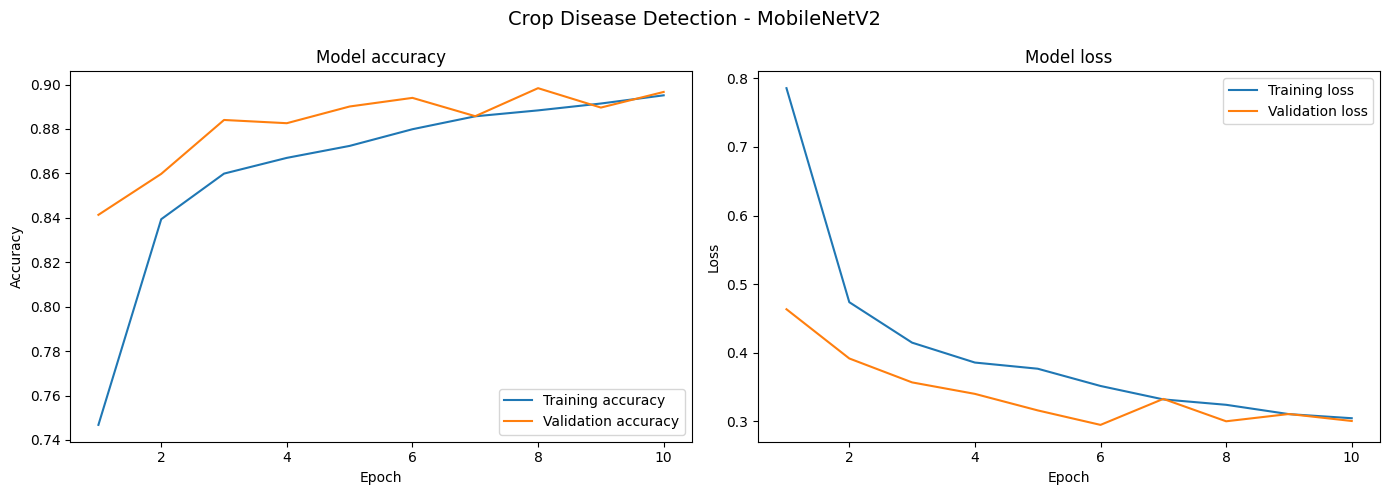

Graph saved as training_curves.png


In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_range, acc, label='Training accuracy')
ax1.plot(epochs_range, val_acc, label='Validation accuracy')
ax1.set_title('Model accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax2.plot(epochs_range, loss, label='Training loss')
ax2.plot(epochs_range, val_loss, label='Validation loss')
ax2.set_title('Model loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.suptitle('Crop Disease Detection - MobileNetV2', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Graph saved as training_curves.png")

129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step


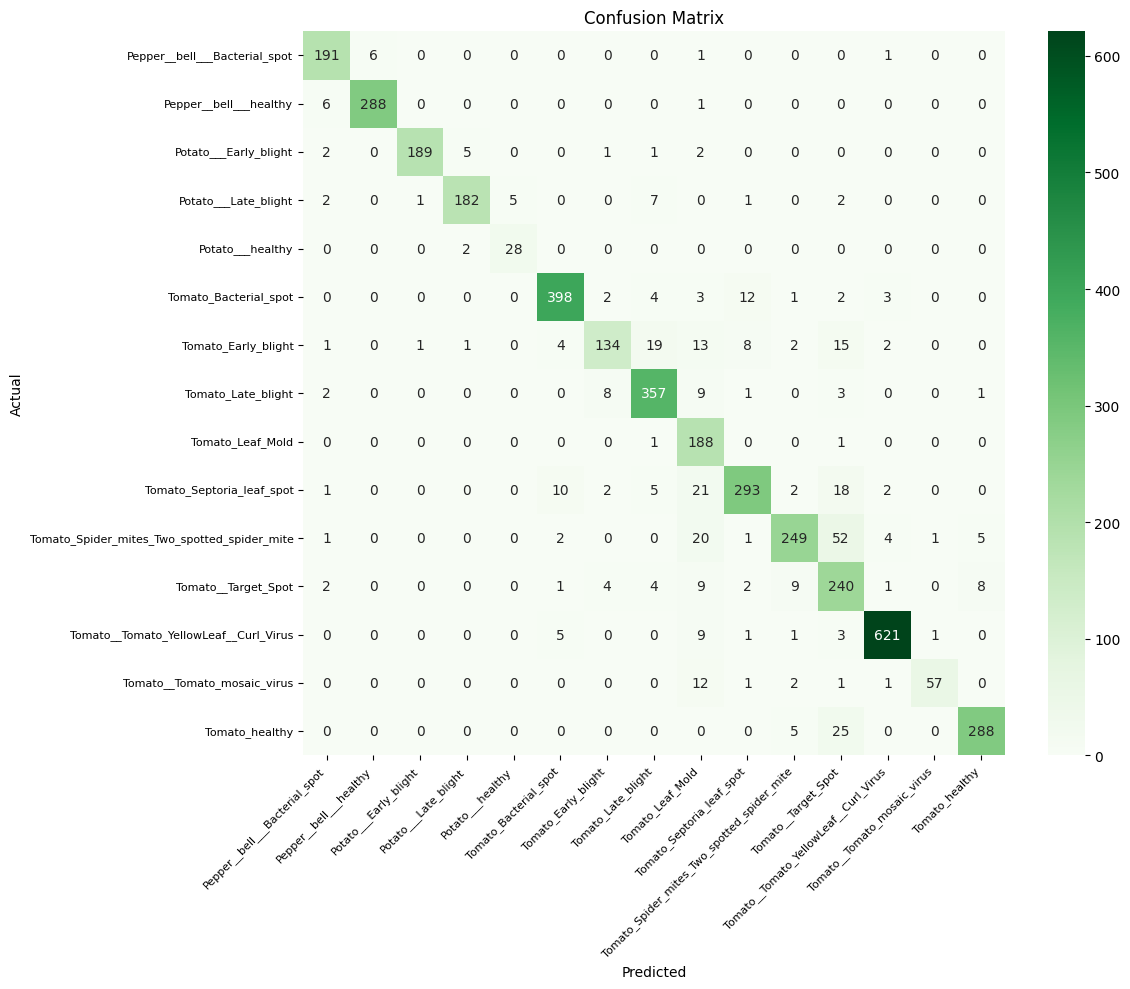


Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.92      0.96      0.94       199
                     Pepper__bell___healthy       0.98      0.98      0.98       295
                      Potato___Early_blight       0.99      0.94      0.97       200
                       Potato___Late_blight       0.96      0.91      0.93       200
                           Potato___healthy       0.85      0.93      0.89        30
                      Tomato_Bacterial_spot       0.95      0.94      0.94       425
                        Tomato_Early_blight       0.89      0.67      0.76       200
                         Tomato_Late_blight       0.90      0.94      0.92       381
                           Tomato_Leaf_Mold       0.65      0.99      0.79       190
                  Tomato_Septoria_leaf_spot       0.92      0.83      0.87       354
Tomato_Spider_mites_Two_spotted_spider_m

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
# Load the best saved model
from tensorflow.keras.models import load_model
best_model = load_model('best_model.h5')
# Get predictions on validation set
val_data.reset()
y_pred = best_model.predict(val_data, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes
# Class names
class_names = list(val_data.class_indices.keys())
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [ ]:
import json
# Save the model in keras format
best_model.save('crop_disease_model.keras')
# Save class names to a JSON file
class_names_dict = val_data.class_indices
class_names_list = [k for k, v in sorted(class_names_dict.items(), key=lambda x: x[1])]
with open('class_names.json', 'w') as f:
    json.dump(class_names_list, f)
print("Model saved as crop_disease_model.keras")
print("Class names saved as class_names.json")
print("\nClasses:")
for i, name in enumerate(class_names_list):
    print(f"  {i}: {name}")

Model saved as crop_disease_model.keras
Class names saved as class_names.json

Classes:
  0: Pepper__bell___Bacterial_spot
  1: Pepper__bell___healthy
  2: Potato___Early_blight
  3: Potato___Late_blight
  4: Potato___healthy
  5: Tomato_Bacterial_spot
  6: Tomato_Early_blight
  7: Tomato_Late_blight
  8: Tomato_Leaf_Mold
  9: Tomato_Septoria_leaf_spot
  10: Tomato_Spider_mites_Two_spotted_spider_mite
  11: Tomato__Target_Spot
  12: Tomato__Tomato_YellowLeaf__Curl_Virus
  13: Tomato__Tomato_mosaic_virus
  14: Tomato_healthy


In [ ]:
from google.colab import files

files.download('crop_disease_model.keras')
files.download('class_names.json')
files.download('training_curves.png')
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save in H5 format (compatible with all Keras versions)
best_model.save('crop_disease_model.h5')
print("Saved as H5!")

Saved as H5!


In [ ]:
from google.colab import files
files.download('crop_disease_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
best_model.save_weights('model_weights.weights.h5')
print("Weights saved!")

Weights saved!


In [ ]:
from google.colab import files
files.download('model_weights.weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
import os
# Copy a few test images
test_dir = '/content/test_samples'
os.makedirs(test_dir, exist_ok=True)

for class_name in ['Tomato_Early_blight', 'Tomato_healthy', 'Potato___Late_blight']:
    class_path = f'/content/plantvillage/PlantVillage/{class_name}'
    img_file = os.listdir(class_path)[0]
    shutil.copy(f'{class_path}/{img_file}', f'{test_dir}/{class_name}.jpg')
    print(f'Saved: {class_name}.jpg')

files.download(f'{test_dir}/Tomato_Early_blight.jpg')
files.download(f'{test_dir}/Tomato_healthy.jpg')
files.download(f'{test_dir}/Potato___Late_blight.jpg')

Saved: Tomato_Early_blight.jpg
Saved: Tomato_healthy.jpg
Saved: Potato___Late_blight.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

# Convert to TFLite format - works across all versions
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

with open('crop_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite model saved!")

Saved artifact at '/tmp/tmp84e1uci5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  134505959511376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134505959512720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134505959512528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134505959512144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134505959513296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134505959511760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134505959512912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134505959513104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134505959511568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134505959514256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13450595951368

In [ ]:
from google.colab import files
files.download('crop_disease_model.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil, os
from google.colab import files

dataset_path = '/content/plantvillage/PlantVillage'

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)
    img_file = os.listdir(class_path)[0]  # take 1 image per class
    src = os.path.join(class_path, img_file)

    # Rename to disease name so you know what it is
    dst = f'/content/{class_name}.jpg'
    shutil.copy(src, dst)
    files.download(dst)
    print(f"Downloaded: {class_name}.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: Pepper__bell___Bacterial_spot.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: Tomato__Tomato_mosaic_virus.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: Tomato_healthy.jpg
